# Install and Import necessary libraries

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
# from prince import FAMD
from scipy.stats import chi2_contingency, f_oneway
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
# from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar 
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold


In [2]:
# Set Seaborn style and Matplotlib parameters for better aesthetics
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300   # publication-quality saved figures
plt.rcParams['savefig.bbox'] = 'tight'

# Upload Cytotoxicity Data and Create DataFrame

In [3]:
# Load Dataset
model = 'cytotoxicity_data'
df = pd.read_csv(f'{model}.csv')

In [4]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (440, 69)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_use', 'addtive3_name', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'cell_line', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'dilution_medium', 'concentration', 'concentration_units', 'dilution', 'incubation_time', 'incubation_time_units', 'incubation_temperature', 'incubation_temperature_units', 'co2_percentage', 'air', 'extraction_time', 'units_extraction_time', 'extraction_temperature', 'units_extraction_t', 'extraction_medium', 'extraction_surface_area_ratio', 'extraction_sur

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [5]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'addtive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'ic_50_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (440, 43)


In [6]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','ic_50', 'growth_constant_μ', 'rgr',
              'toxicity_grade','zone_index','lysis_index', 'growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 35)


In [7]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type', # derived from cell_line
                  #'polymer_percentage' # =100-(additive1+additive2+additive3)percentage =
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 33)


# Train/Test Split

In [8]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (11):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - air
  - extraction_medium


In [9]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]
print(f"After dropping rows with null target values: {df.shape}")

After dropping rows with null target values: (413, 33)


In [10]:
# Split the dataset into training and testing sets with stratification to maintain class distribution
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (330, 32) class proportions toxicity
non-toxic    253
toxic         77
Name: count, dtype: int64

Test size (83, 32) class proportions toxicity
non-toxic    64
toxic        19
Name: count, dtype: int64


In [11]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
print(missing_df)

Total rows: 330

                               Missing Values  Missing Percentage (%)
surface                                   326                    98.8
number_of_cells_well                      319                    96.7
extraction_medium                         309                    93.6
extraction_time                           309                    93.6
extraction_temperature                    303                    91.8
extraction_surface_area_ratio             294                    89.1
diameter                                  286                    86.7
thickness                                 272                    82.4
dilution                                  267                    80.9
pdi                                       262                    79.4
mn                                        223                    67.6
mw                                        202                    61.2
length                                    199                    60.3
dil

In [12]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
                            c for c in X_train.columns
                            if X_train[c].isnull().sum() / len(X_train) > miss_thresh
                            and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
                            ]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (109, 15) class proportions toxicity
non-toxic    86
toxic        23
Name: count, dtype: int64

Test size (27, 15) class proportions toxicity
non-toxic    21
toxic         6
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

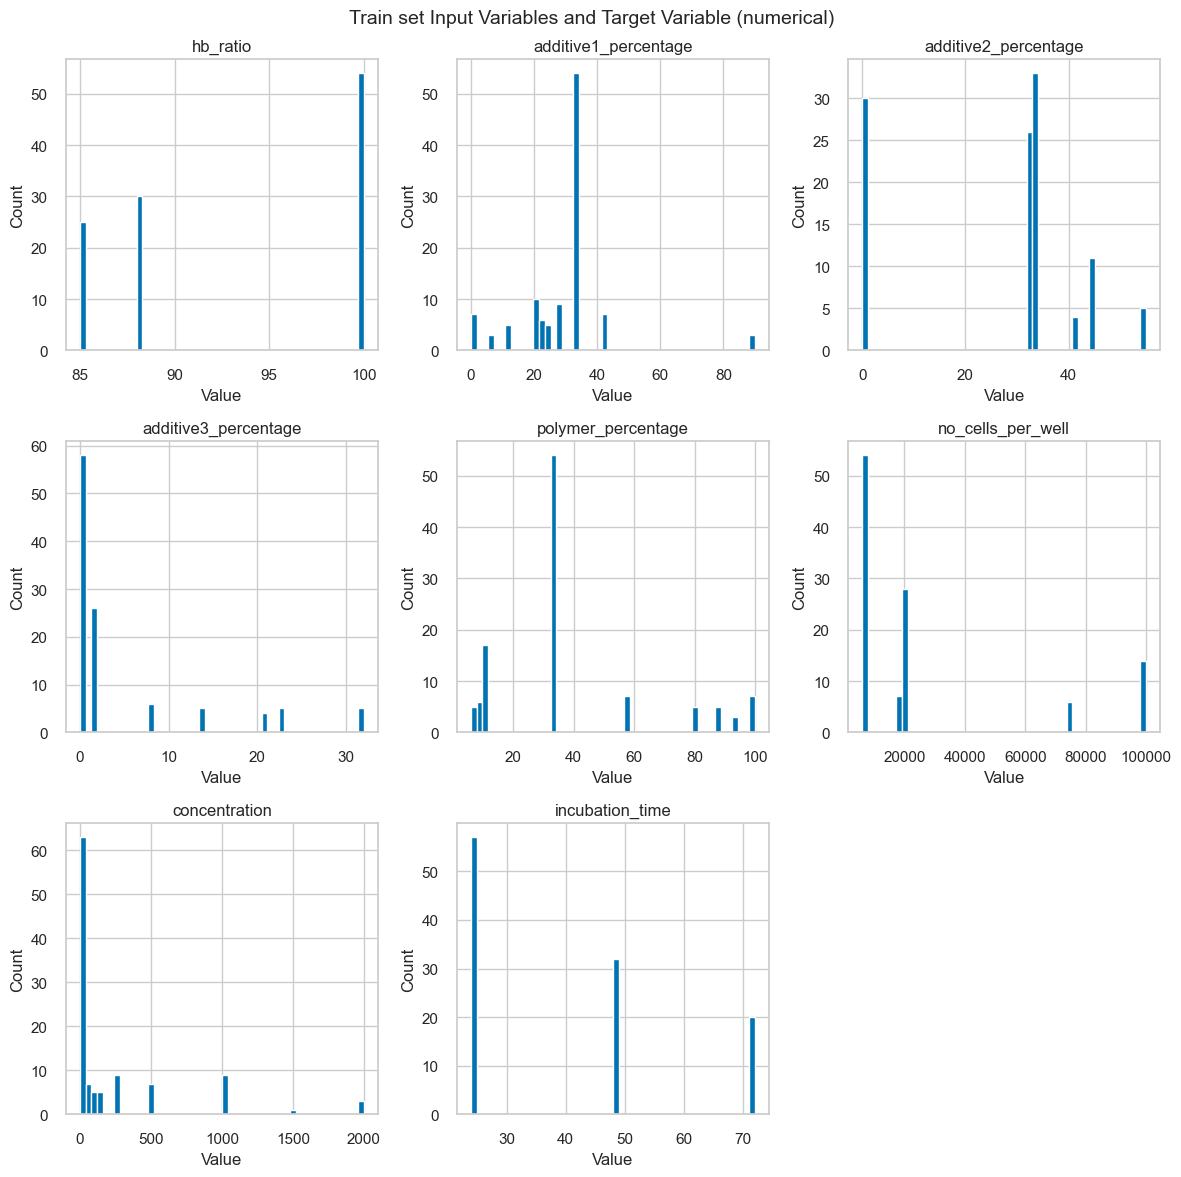

In [13]:
# Plot histograms of all numerical features
axes = X_train.hist(bins=50, figsize=(12, 12))

for ax_row in axes:
    for ax in ax_row:
        if ax.has_data():
            ax.set_ylabel('Count')
            ax.set_xlabel('Value')

plt.suptitle('Train set Input Variables and Target Variable (numerical)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (8):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - incubation_time

Categorical features (7):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


In [15]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.eda import plot_distributions, class_balance, plot_boxplots, correlation_heatmap, mutual_information

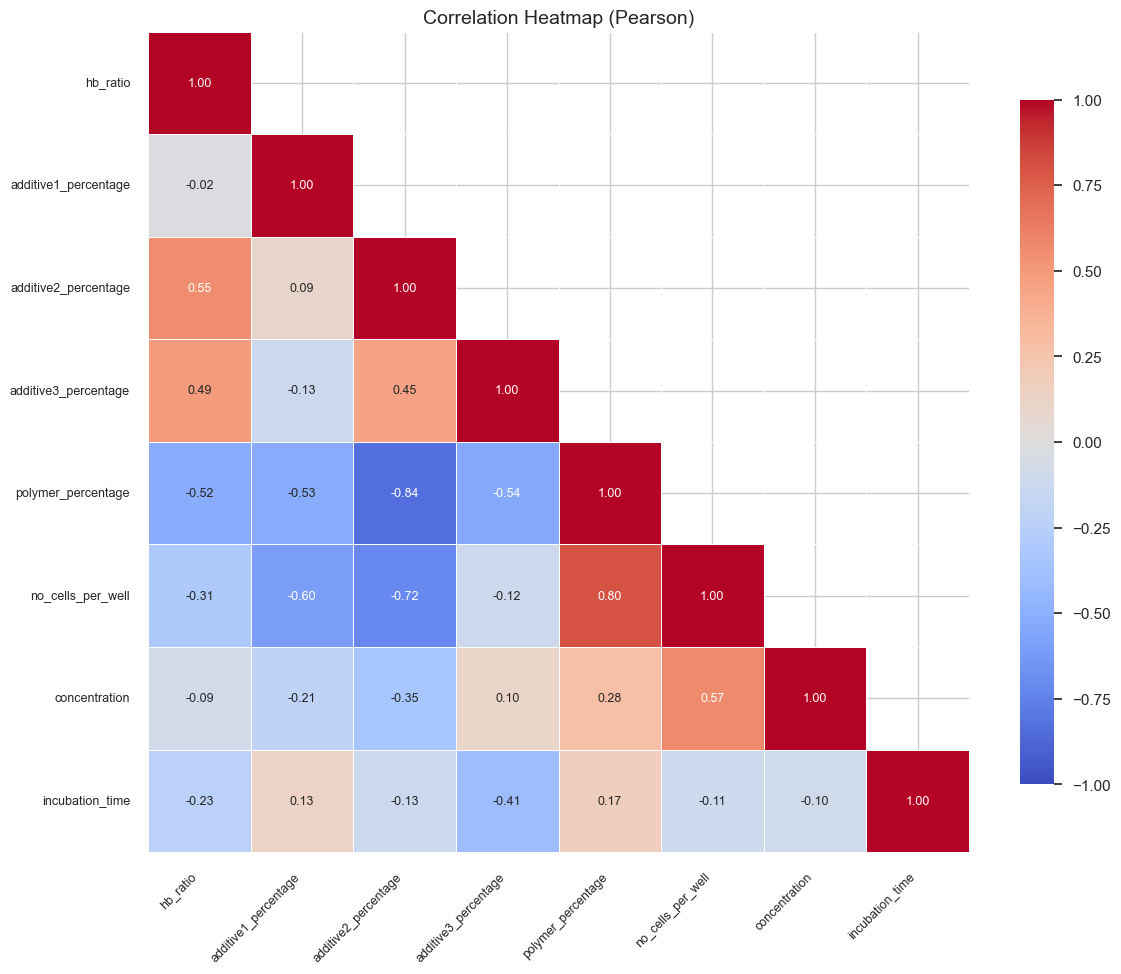

In [16]:
correlation_heatmap(X_train)

In [19]:
from src.iqr_method import detect_outliers_iqr,  remove_outliers_iqr 

summary = detect_outliers_iqr(X_train)
print(summary)

                feature    n  n_outliers  pct_outliers      q1   median  \
0              hb_ratio  109           0           0.0    88.0     88.0   
1  additive1_percentage  109          13          11.9    23.0     32.9   
2  additive2_percentage  109           0           0.0     0.0     32.9   
3  additive3_percentage  109          25          22.9     0.0      0.0   
4    polymer_percentage  109          20          18.3    11.0     32.9   
5     no_cells_per_well  109          20          18.3  6000.0  19000.0   
6         concentration  109          13          11.9     1.3      6.0   
7       incubation_time  109           0           0.0    24.0     24.0   

         q3       iqr  lower_bound  upper_bound  \
0    100.00     12.00       70.000      118.000   
1     33.33     10.33        7.505       48.825   
2     33.33     33.33      -49.995       83.325   
3      1.32      1.32       -1.980        3.300   
4     33.33     22.33      -22.495       66.825   
5  20000.00  14000

In [ ]:
X_clean, y_clean, mask = remove_outliers_iqr(X_train, y_train)

Removed 48 rows (44.0%)
Remaining: 61 rows


In [29]:
X_train.shape

(109, 15)

In [24]:
remove_outliers_iqr(X_train, y_train)[1]

Removed 48 rows (44.0%)
Remaining: 61 rows


357    non-toxic
360    non-toxic
355    non-toxic
57         toxic
306    non-toxic
         ...    
342    non-toxic
365        toxic
349    non-toxic
371        toxic
344    non-toxic
Name: toxicity, Length: 61, dtype: object

In [73]:
summary["outlier_values"][3]

[79.7,
 79.7,
 79.7,
 79.7,
 79.7,
 87.5,
 87.5,
 87.5,
 87.5,
 87.5,
 93.4,
 93.4,
 93.4,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0]

In [ ]:
src.remove_outliers_iqr()


NameError: name 'src' is not defined

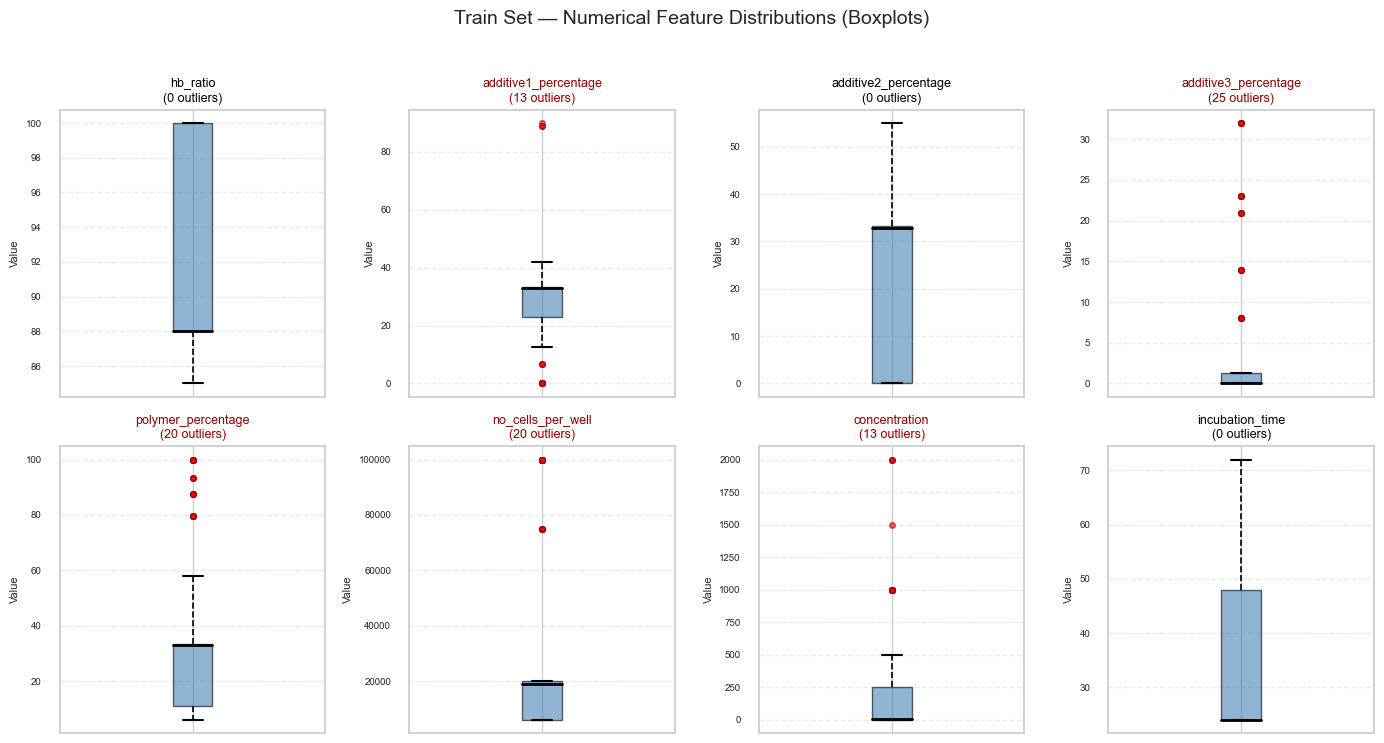

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    data = X_train[col].dropna()
    
    # Boxplot with outlier styling
    bp = ax.boxplot(
        data,
        patch_artist=True,
        notch=False,
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='darkred',
            markersize=4,
            alpha=0.6,
            linestyle='none'
        ),
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        whiskerprops=dict(linestyle='--', linewidth=1.2),
        capprops=dict(linewidth=1.5)
    )
    
    # IQR-based outlier count annotation
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    
    ax.set_title(f'{col}\n({n_outliers} outliers)', fontsize=9,
                 color='darkred' if n_outliers > 0 else 'black')
    ax.set_xlabel('')
    ax.set_ylabel('Value', fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Train Set — Numerical Feature Distributions (Boxplots)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

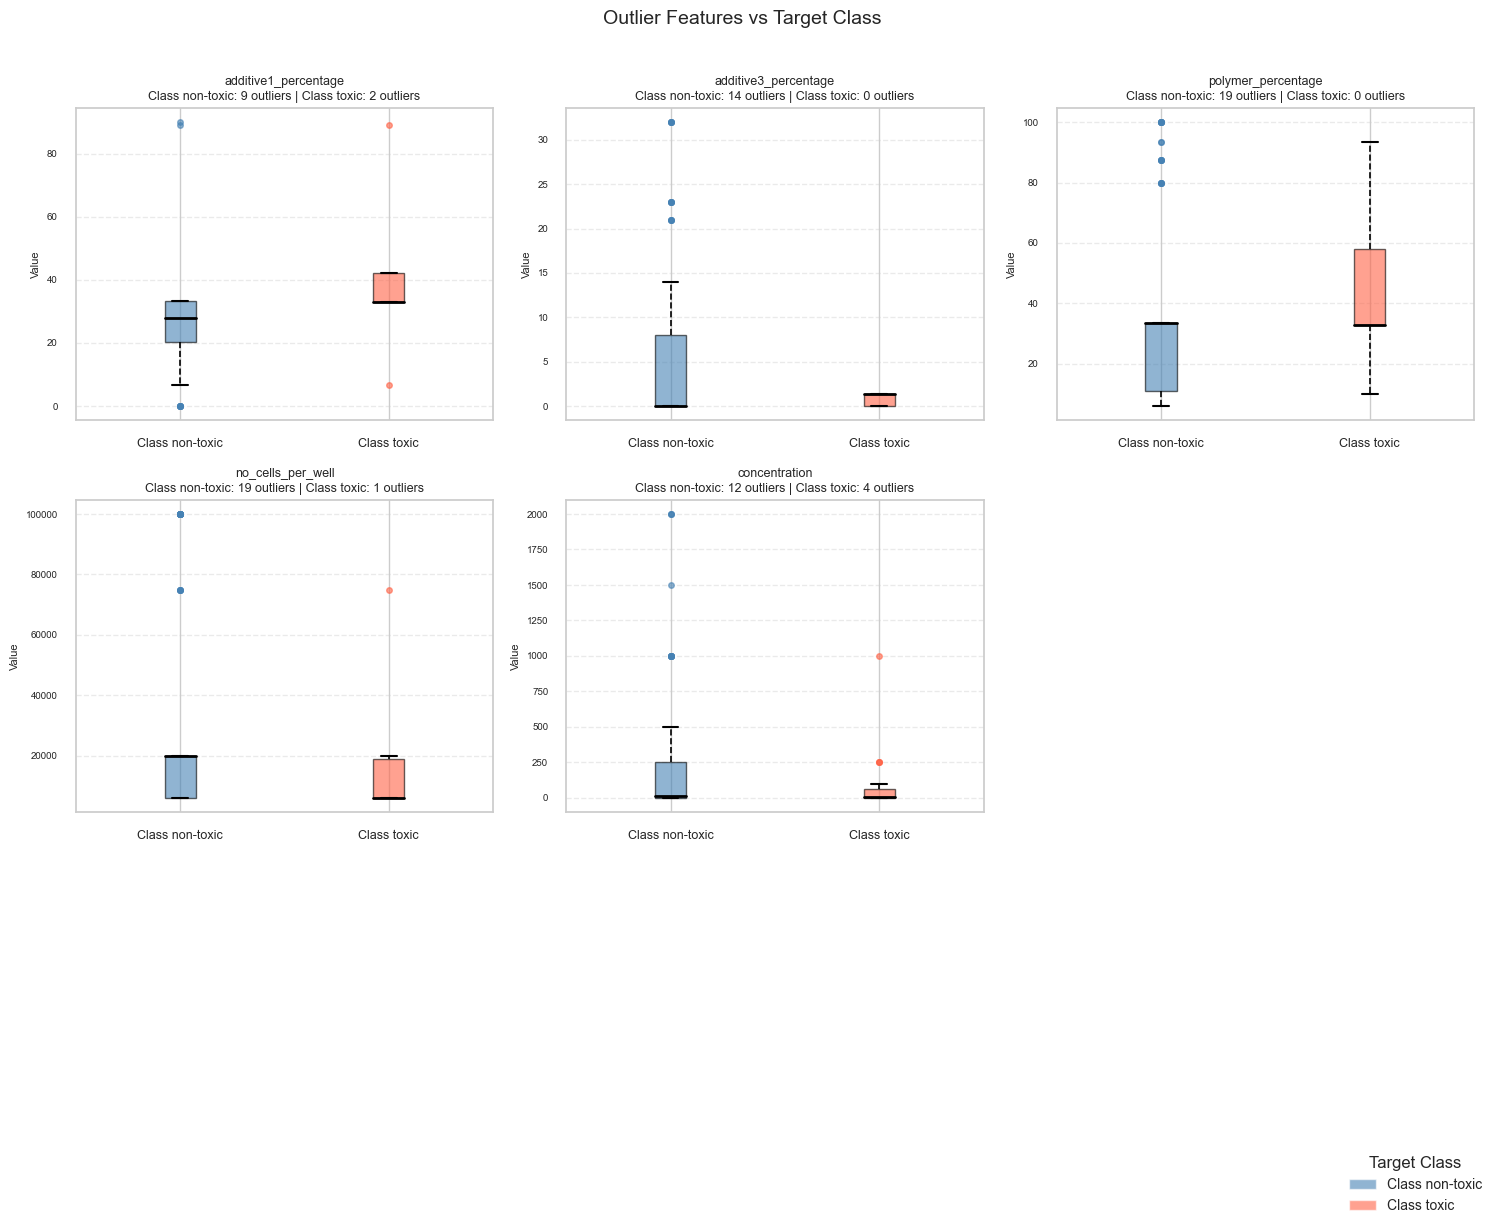

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Only features with outliers
outlier_cols = [
    'additive1_percentage', 'additive3_percentage',
    'polymer_percentage', 'no_cells_per_well', 'concentration'
]

# Assumes your full training dataframe is X_train with y_train aligned
df_plot = X_train[outlier_cols].copy()
df_plot['target'] = y_train.values  # or y_train.reset_index(drop=True)

target_classes = sorted(df_plot['target'].unique())
colors = ['steelblue', 'tomato']  # adjust if you have more classes

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    
    groups = [df_plot[df_plot['target'] == cls][col].dropna() for cls in target_classes]
    
    bp = ax.boxplot(
        groups,
        patch_artist=True,
        notch=False,
        flierprops=dict(
            marker='o', markersize=4, alpha=0.6, linestyle='none'
        ),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linestyle='--', linewidth=1.2),
        capprops=dict(linewidth=1.5)
    )
    
    # Color each box by class
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Color outlier dots to match their box
    flier_idx = 0
    for j, flier in enumerate(bp['fliers']):
        flier.set(markerfacecolor=colors[j], markeredgecolor=colors[j])
    
    # Outlier counts per class
    subtitles = []
    for cls, grp in zip(target_classes, groups):
        Q1, Q3 = grp.quantile(0.25), grp.quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((grp < Q1 - 1.5 * IQR) | (grp > Q3 + 1.5 * IQR)).sum()
        subtitles.append(f'Class {cls}: {n_out} outliers')
    
    ax.set_title(f'{col}\n' + ' | '.join(subtitles), fontsize=9)
    ax.set_xticks(range(1, len(target_classes) + 1))
    ax.set_xticklabels([f'Class {cls}' for cls in target_classes], fontsize=9)
    ax.set_ylabel('Value', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=f'Class {cls}')
                   for i, cls in enumerate(target_classes)]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=10, title='Target Class')

for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Features vs Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
log_transform_cols = ['additive3_percentage', 'concentration', 'no_cells_per_well']

for col in log_transform_cols:
    X_train[f'{col}_log'] = np.log1p(X_train[col])
    X_test[f'{col}_log'] = np.log1p(X_test[col])

# Drop originals
X_train.drop(columns=log_transform_cols, inplace=True)
X_test.drop(columns=log_transform_cols, inplace=True)

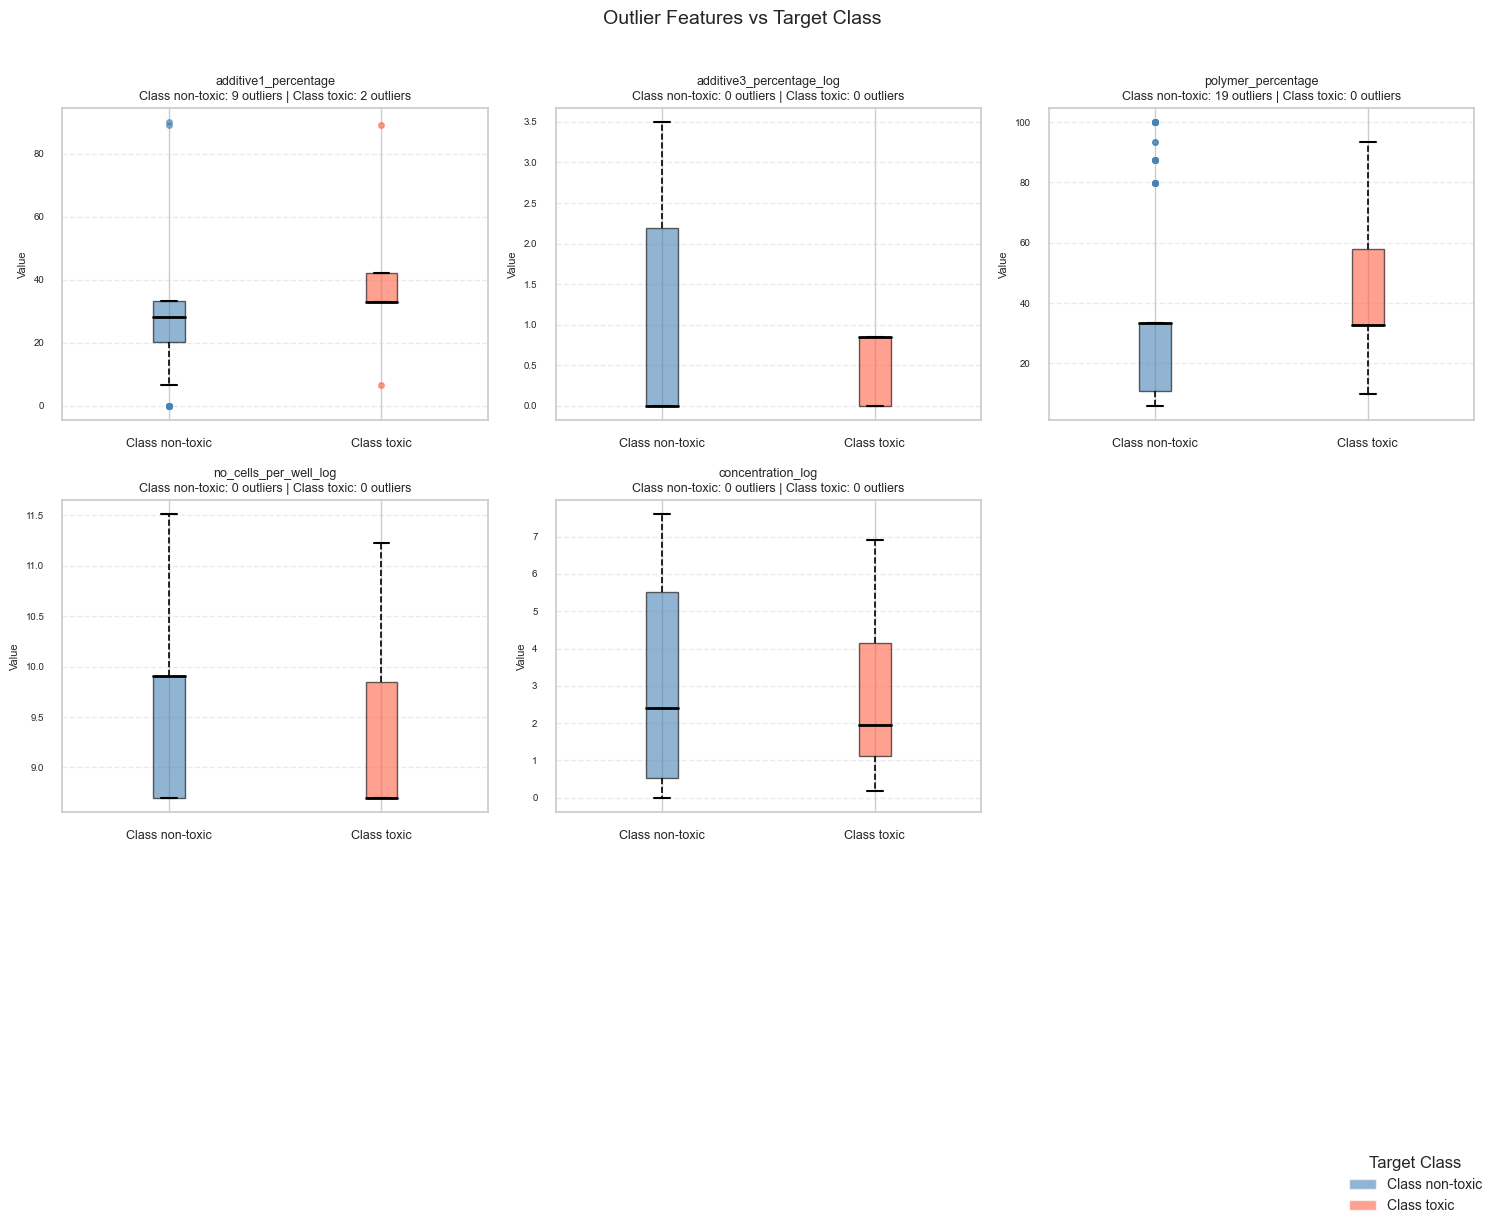

In [18]:

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Only features with outliers
outlier_cols = [
    'additive1_percentage',
    'additive3_percentage_log',  # renamed
    'polymer_percentage',
    'no_cells_per_well_log',     # renamed
    'concentration_log'          # renamed
]


# Assumes your full training dataframe is X_train with y_train aligned
df_plot = X_train[outlier_cols].copy()
df_plot['target'] = y_train.values  # or y_train.reset_index(drop=True)

target_classes = sorted(df_plot['target'].unique())
colors = ['steelblue', 'tomato']  # adjust if you have more classes

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    
    groups = [df_plot[df_plot['target'] == cls][col].dropna() for cls in target_classes]
    
    bp = ax.boxplot(
        groups,
        patch_artist=True,
        notch=False,
        flierprops=dict(
            marker='o', markersize=4, alpha=0.6, linestyle='none'
        ),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linestyle='--', linewidth=1.2),
        capprops=dict(linewidth=1.5)
    )
    
    # Color each box by class
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Color outlier dots to match their box
    flier_idx = 0
    for j, flier in enumerate(bp['fliers']):
        flier.set(markerfacecolor=colors[j], markeredgecolor=colors[j])
    
    # Outlier counts per class
    subtitles = []
    for cls, grp in zip(target_classes, groups):
        Q1, Q3 = grp.quantile(0.25), grp.quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((grp < Q1 - 1.5 * IQR) | (grp > Q3 + 1.5 * IQR)).sum()
        subtitles.append(f'Class {cls}: {n_out} outliers')
    
    ax.set_title(f'{col}\n' + ' | '.join(subtitles), fontsize=9)
    ax.set_xticks(range(1, len(target_classes) + 1))
    ax.set_xticklabels([f'Class {cls}' for cls in target_classes], fontsize=9)
    ax.set_ylabel('Value', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=f'Class {cls}')
                   for i, cls in enumerate(target_classes)]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=10, title='Target Class')

for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Features vs Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
#     print("\n")
#     print(X_train[column].describe())

In [20]:
# # Check heavily skewed features (high value of std)

# ## Plot a histogram of the distribution of no_cells_per_well
# X_train['no_cells_per_well'].hist(bins=100), #edgecolor='black')
# plt.xlabel('no_cells_per_well')
# plt.ylabel('Frequency')
# plt.title('Distribution of no_cells_per_well')
# plt.tight_layout()
# # plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
# plt.show()
# ## Check to decide boundaries of no_cells_per_well
# print('\n')
# print(X_train['no_cells_per_well'].value_counts().sort_index())

# ## Plot a histogram of the distribution of concentration
# X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
# plt.xlabel('concentration')
# plt.ylabel('Frequency')
# plt.title('Distribution of concentration')
# plt.tight_layout()
# # plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
# plt.show()
# ## Check to decide boundaries of concentration
# print('\n')
# print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [21]:
# X_train['no_cells_per_well'].value_counts()

In [22]:
# # Categorise no_cells_per_wel feature
# bins = [0, 10_000, 50_000, float('inf')]
# labels = ['low', 'medium', 'high']

# X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
# X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# # Check the categories frequency
# print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
# print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

In [23]:
# # Categorise concetration
# bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
# labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

# X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
# X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# # Check the categories frequency
# print(f"Train set: {X_train['concentration'].value_counts()}")
# print(f"\nTest set: {X_test['concentration'].value_counts()}")

## Outlier Detection

In [24]:
# No outlier detection due to data shortage
X_train_clean = X_train.copy()
y_train_clean = y_train.copy()

## Handle Categorical Features

In [25]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X


# ── Pipeline ──────────────────────────────────────────────────────────────────

cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 1: collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Step 2: merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

[shape] 'other' has only 1 rows → merging into 'tetra_arm_star'
[culture_medium] 'other' has only 3 rows → merging into 'dmem_fbs_p/s'


In [26]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



shape
nanospheres       54
microsphere       20
diblock_star      18
nanoparticle      10
tetra_arm_star     7
Name: count, dtype: int64


additive1_use
targeting_ligand    54
responsive          25
filler              10
not_applicable       7
anticancer           7
other                6
Name: count, dtype: int64


additive2_use
stabilizer        54
not_applicable    30
stealth           25
Name: count, dtype: int64


additive3_use
not_applicable    58
active_drug       26
hydrophobe        25
Name: count, dtype: int64


assay
mtt        89
diic1_5    14
mts         6
Name: count, dtype: int64


cell_line
mcf7          54
ccd_112con    25
jurkat        11
a549           7
hepg2          6
other          6
Name: count, dtype: int64


culture_medium
dmem_10fbs_pen_strep    60
dmem_fp                 25
rpmi-1640               14
dmem_fbs_p/s            10
Name: count, dtype: int64


In [27]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 109 rows | Test: 27 rows


# Feature Selection 

In [28]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (8):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - polymer_percentage
  - incubation_time
  - additive3_percentage_log
  - concentration_log
  - no_cells_per_well_log

Categorical features (7):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


## Mutual Information 

In [29]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[categorical_cols] = ordinal_encoder.fit_transform(X_train_encoded[categorical_cols])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in categorical_cols], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)

Mutual Information Scores:
additive1_percentage        0.262162
polymer_percentage          0.259880
additive1_use               0.196738
cell_line                   0.182172
culture_medium              0.159840
shape                       0.149442
no_cells_per_well_log       0.139250
additive2_percentage        0.136667
additive3_use               0.121013
additive3_percentage_log    0.090538
additive2_use               0.063648
assay                       0.033872
incubation_time             0.032526
hb_ratio                    0.000000
concentration_log           0.000000
dtype: float64


In [30]:
# encoder = OrdinalEncoder(
#     handle_unknown="use_encoded_value",
#     unknown_value=-1
# )
# X_train_encoded = X_train_clean.copy()
# X_train_encoded[categorical_cols] = encoder.fit_transform(
#     X_train_clean[categorical_cols]
# )

In [31]:
# discrete_mask = [col in categorical_cols for col in X_train_encoded.columns]

# mi_scores = mutual_info_classif(
#     X_train_encoded, y_train_clean,
#     discrete_features=discrete_mask,
#     random_state=42
# )
# mi_df = pd.DataFrame({
#     "feature"  : X_train_encoded.columns,
#     "mi_score" : mi_scores
# }).sort_values("mi_score", ascending=False).reset_index(drop=True)

# print("=== Mutual Information (vs target) ===")
# print(mi_df.to_string(index=False))

## Spearman (Num vs Num)

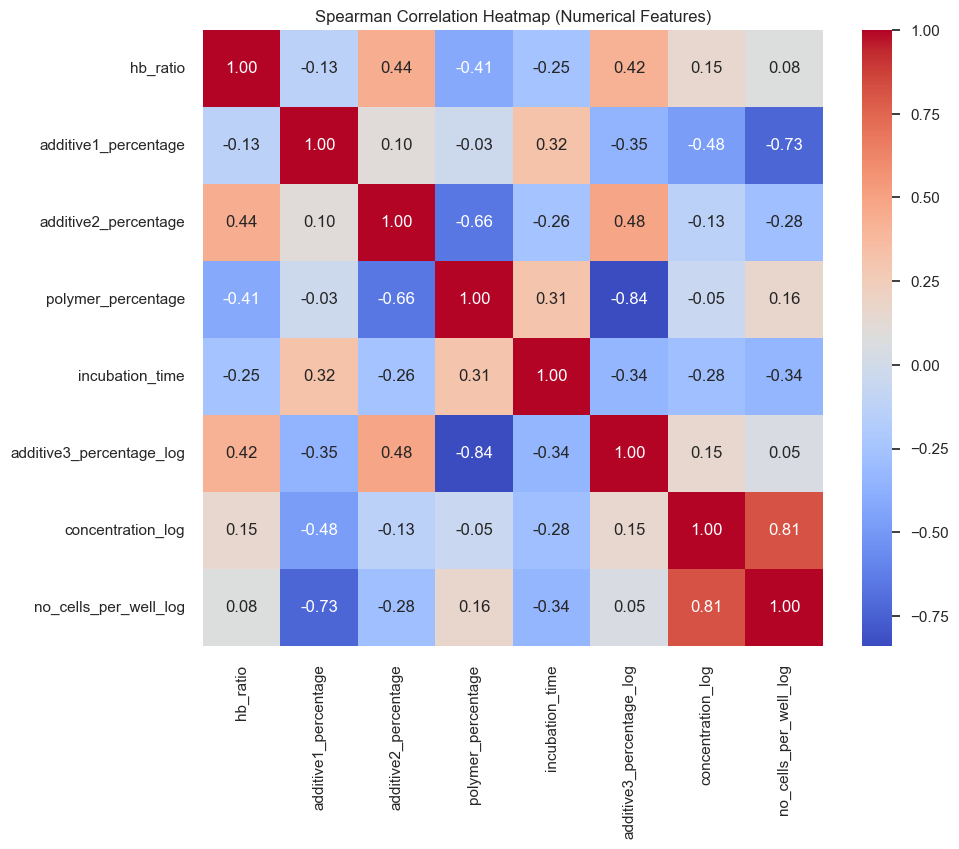

In [32]:
# Use Spearman correlation for numerical features between them
spearman_corr = X_train_clean[numerical_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap (Numerical Features)')
plt.show()

In [33]:
# spearman_matrix = (
#     X_train_clean[numerical_cols]
#     .corr(method="kendall") # or spearman for non normally distributed variables
#     .abs()
# )
# print("=== Spearman Correlation (numerical vs numerical) ===")
# spearman_matrix.round(2)

## Cramér's V (Cat vs Cat)

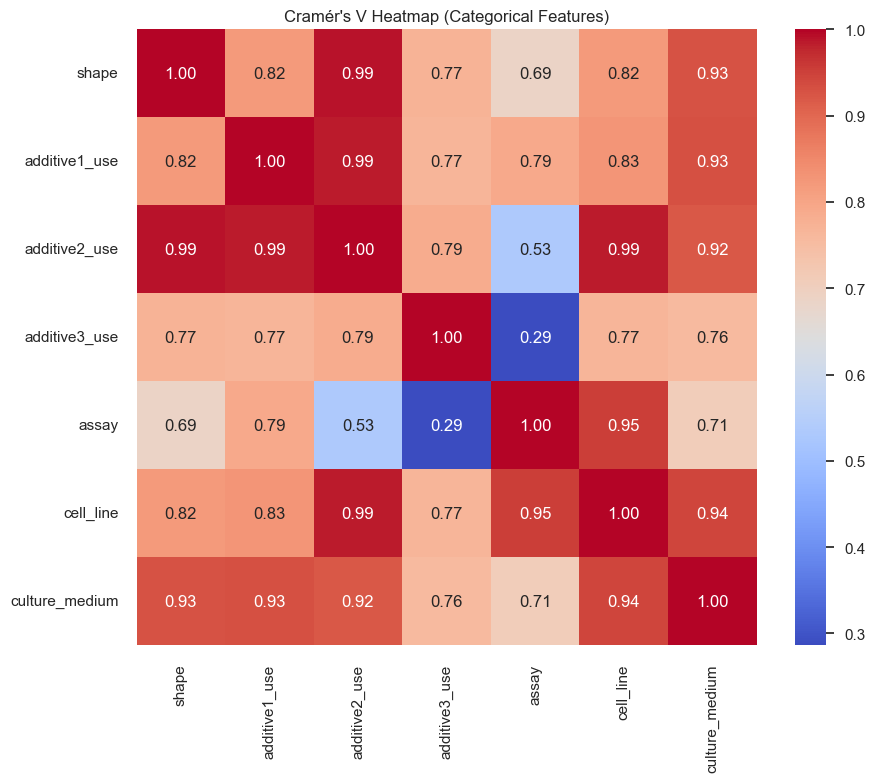

In [34]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

In [35]:
# def cramers_v(col_a, col_b):
#     contingency = pd.crosstab(col_a, col_b)
#     chi2, _, _, _ = chi2_contingency(contingency)
#     n = contingency.values.sum()
#     r, k = contingency.shape
#     denom = n * (min(r, k) - 1)
#     return np.sqrt(chi2 / denom) if denom > 0 else 0.0

# cat_cols = categorical_cols
# cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

# for col_a in cat_cols:
#     for col_b in cat_cols:
#         if col_a == col_b:
#             cramers_matrix.loc[col_a, col_b] = 1.0  # skip computation, always 1
#         else:
#             cramers_matrix.loc[col_a, col_b] = cramers_v(
#                 X_train_clean[col_a], X_train_clean[col_b]
#             )

# print("=== Cramér's V (categorical vs categorical) ===")
# cramers_matrix.round(2)

## Drop Unnecessary Features

In [36]:
# mi_threshold = 0.05  # adjust as needed
# features_to_keep = mi_df[mi_df['mi_score'] >= mi_threshold]['feature'].tolist()

# X_train_clean = X_train_clean[features_to_keep]
# X_test_clean  = X_test_clean[features_to_keep]

# Machine Learning Algorithm

In [37]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (8):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - polymer_percentage
  - incubation_time
  - additive3_percentage_log
  - concentration_log
  - no_cells_per_well_log

Categorical features (7):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


In [38]:
features_num = numerical_cols
features_cat = categorical_cols 

In [39]:
# Preprocessing pipeline
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)

# Fit the preprocessor on the training data and transform both train and test sets
X_train_preprocessed = pre.fit_transform(X_train_clean)
X_test_preprocessed  = pre.transform(X_test_clean)

# Label encode the target variable for PyCaret and convert to DataFrame for easier handling ('Non_Toxic' -> 0, 'Toxic' -> 1)
label_encoder = LabelEncoder()
# y_train_clean = label_encoder.fit_transform(y_train_clean)
# y_test_clean  = label_encoder.transform(y_test_clean)
y_train_clean = pd.Series(label_encoder.fit_transform(y_train_clean), index=X_train_clean.index)
y_test_clean  = pd.Series(label_encoder.transform(y_test_clean), index=X_test_clean.index)    


# Get feature names after one-hot encoding
ohe_feature_names = pre.named_transformers_["cat"].get_feature_names_out(features_cat)
feature_names = features_num + list(ohe_feature_names)
print(f"Total features after preprocessing: {len(feature_names)}")

# Convert back to DataFrame for easier handling
X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names) 

# Join the target back to the preprocessed features for PyCaret
train_data = X_train_df.copy()
train_data[target] = y_train_clean.values

test_data = X_test_df.copy()
test_data[target] = y_test_clean.values


Total features after preprocessing: 38


In [40]:
# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data,
            target=target,
            preprocess=False,          # data already preprocessed
            fix_imbalance=True,
            # fold=5,
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42),
            index=False,
            session_id=42)

# Compare models and select the best one based on AUC
best_model = compare_models(sort='auc', n_select=1)
print(f"Best model: {best_model}")

,Description,Value
0,Session id,42
1,Target,toxicity
2,Target type,Binary
3,Original data shape,"(136, 39)"
4,Transformed data shape,"(136, 39)"
5,Transformed train set shape,"(109, 39)"
6,Transformed test set shape,"(27, 39)"
7,Numeric features,38


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9045,0.9632,0.7520,0.8196,0.7657,0.7071,0.7209,0.0684
rf,Random Forest Classifier,0.9081,0.9626,0.7500,0.8199,0.7695,0.7129,0.7234,0.0120
ridge,Ridge Classifier,0.8829,0.9562,0.7340,0.7913,0.7269,0.6562,0.6792,0.0024
gbc,Gradient Boosting Classifier,0.9139,0.9555,0.7920,0.8299,0.7975,0.7437,0.7535,0.0052
ada,Ada Boost Classifier,0.9139,0.9452,0.8180,0.8110,0.8030,0.7489,0.7575,0.0048
lda,Linear Discriminant Analysis,0.8698,0.9440,0.7860,0.6924,0.7174,0.6360,0.6522,0.0016
xgboost,Extreme Gradient Boosting,0.9064,0.9396,0.7380,0.8409,0.7586,0.7040,0.7227,0.0040
lr,Logistic Regression,0.9028,0.9357,0.6820,0.8591,0.7368,0.6803,0.7005,0.1184
knn,K Neighbors Classifier,0.8754,0.9318,0.7740,0.7179,0.7267,0.6487,0.6623,0.0016
lightgbm,Light Gradient Boosting Machine,0.8992,0.9301,0.7660,0.7852,0.7597,0.6972,0.7083,0.0332


Best model: CatBoostClassifier(border_count=254, random_state=42, task_type='CPU', verbose=False)


In [41]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(best_model,
                         optimize='auc',
                         search_library='optuna',
                         n_iter=50,
                         )
# Check the best hyperparameters found
print("Best hyperparameters:", tuned_model.get_params())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9091,0.9583,0.5000,1.0000,0.6667,0.6207,0.6708
1,0.8636,0.9353,0.8000,0.6667,0.7273,0.6374,0.6421
2,0.9091,1.0000,1.0000,0.7143,0.8333,0.7732,0.7939
3,0.9545,0.9824,0.8000,1.0000,0.8889,0.8608,0.8692
4,0.9524,1.0000,0.7500,1.0000,0.8571,0.8293,0.8416
5,0.9091,0.9792,0.7500,0.7500,0.7500,0.6944,0.6944
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.9091,0.8941,1.0000,0.7143,0.8333,0.7732,0.7939
8,0.9545,0.9882,0.8000,1.0000,0.8889,0.8608,0.8692


Best hyperparameters: {'depth': 3, 'l2_leaf_reg': 9, 'border_count': 254, 'verbose': False, 'random_strength': 0.292391993370304, 'task_type': 'CPU', 'n_estimators': 64, 'random_state': 42, 'eta': 0.35287931175260207}


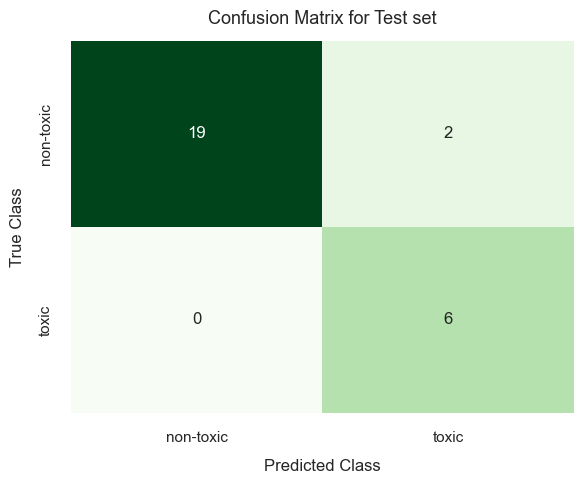

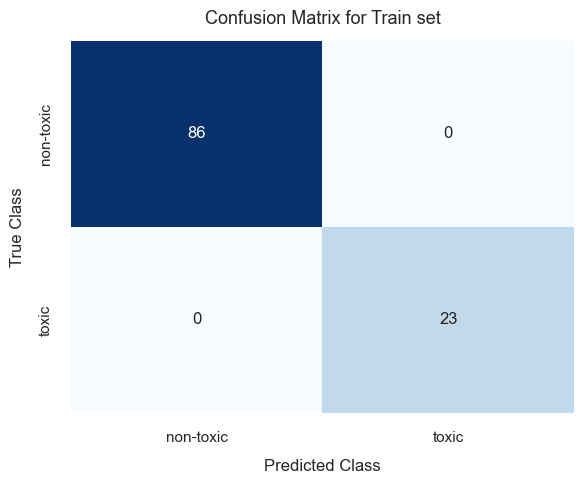

In [42]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = label_encoder.classes_
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    # plt.show()
    plt.show() 
# TEST SET
X_test_pred = tuned_model.predict(X_test_df)
cm_test = confusion_matrix(y_test_clean, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set', 'Greens') 
# TRAIN SET
X_train_pred = tuned_model.predict(X_train_df)
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set', 'Blues')



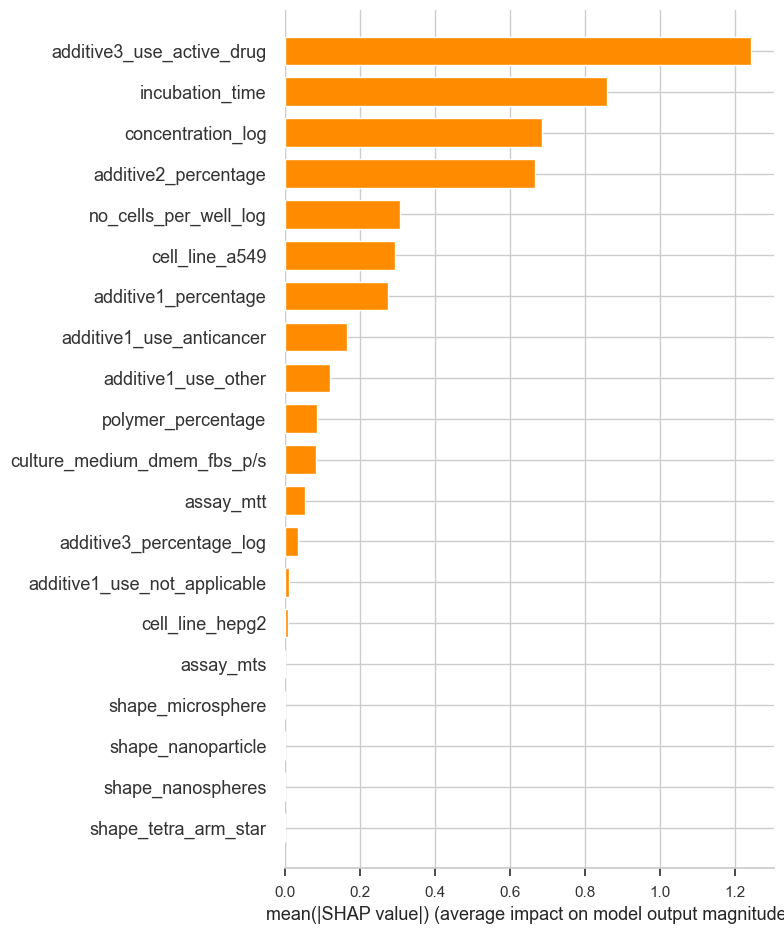

In [43]:
# Check SHAP values for the tuned model to understand feature importance and contribution to predictions
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, plot_type="bar", show=False, color='darkorange')
plt.tight_layout()
# plt.savefig('shap_summary_plot.png', dpi=600, bbox_inches='tight')
plt.show()

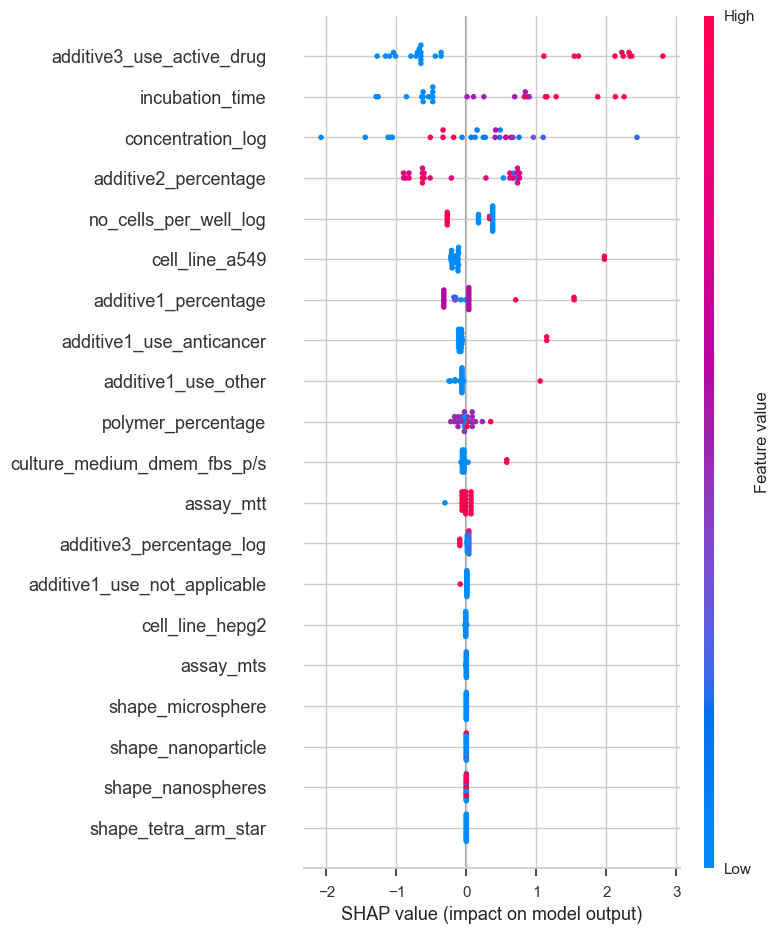

In [44]:
# Check SHAP tree explainers for the tuned model to understand feature interactions and contribution to predictions
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, plot_type="dot", show=False)
plt.tight_layout()
# plt.savefig('shap_summary_plot_dot.png', dpi=600, bbox_inches='tight')
plt.show()

In [45]:
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)


clf = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample"
    )
    )
])

Fitting 5 folds for each of 504 candidates, totalling 2520 fits
Best params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 50}
Best CV score: 0.8740 ± 0.0528


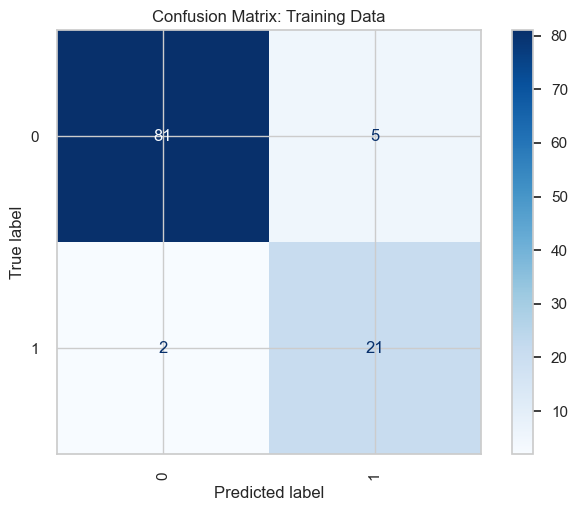

In [46]:
param_grid = {
    "rf__n_estimators": [20, 40, 50, 100, 200, 400, 500],
    "rf__max_depth": [None, 10, 20, 40],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True,
    random_state=42
)


grid = GridSearchCV(
    clf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1 # or 2 to check more information 
)

grid.fit(X_train_clean, y_train_clean)
best_clf = grid.best_estimator_ 

std_cv = grid.cv_results_["std_test_score"][grid.best_index_]

cmd = ConfusionMatrixDisplay.from_estimator(
    best_clf, 
    X_train_clean, 
    y_train_clean, 
    display_labels=best_clf.classes_, 
    cmap=plt.cm.Blues,                
    xticks_rotation='vertical'        
)



print("Best params:", grid.best_params_)
print(f"Best CV score: {grid.best_score_:.4f} ± {std_cv:.4f}")

plt.title("Confusion Matrix: Training Data")
# plt.savefig('Confusion_Matrix_Train.png', dpi=600, bbox_inches='tight')
plt.show()

In [47]:
for col in features_cat:
    train_cats = set(X_train_clean[col].unique())
    test_cats  = set(X_test_clean[col].unique())
    
    unseen = test_cats - train_cats
    
    if unseen:
        print(f"[{col}] Dropping {len(unseen)} unseen categories: {unseen}")
        X_test_clean = X_test_clean[~X_test_clean[col].isin(unseen)]

# realign y_test after row drops
y_test_clean   = y_test_clean.loc[X_test_clean.index].reset_index(drop=True)
X_test_clean = X_test_clean.reset_index(drop=True)

print(f"\nX_test rows remaining: {len(X_test_clean)}")
assert len(X_test_clean) == len(y_test_clean)

[culture_medium] Dropping 1 unseen categories: {'dmem_g1_f10_a6'}

X_test rows remaining: 26



=== Test metrics ===
Accuracy: 0.8461538461538461
Balanced Accuracy: 0.8416666666666667
Matthews CorrCoef: 0.6237951349364392
Macro F1: 0.8045112781954887
Precision (per class): [0.94444444 0.625     ]
Recall (per class): [0.85       0.83333333]
F1 (per class): [0.89473684 0.71428571]
Jaccard (per class): [0.80952381 0.55555556]
Confusion Matrix:
 [[17  3]
 [ 1  5]]


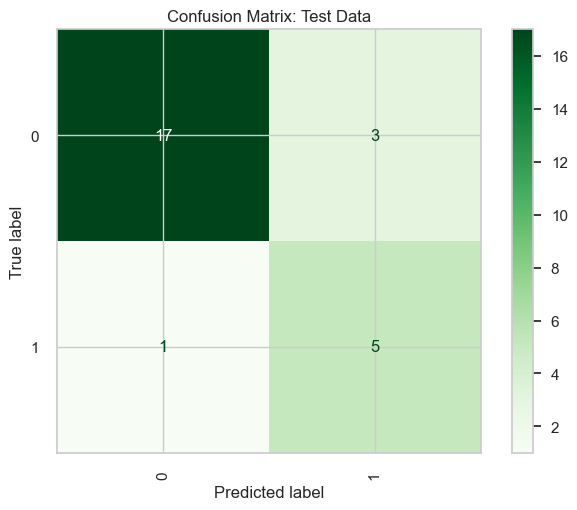

In [48]:
y_pred = best_clf.predict(X_test_clean)

print("\n=== Test metrics ===")

# Overall metrics
print("Accuracy:", accuracy_score(y_test_clean, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_clean, y_pred))
print("Matthews CorrCoef:", matthews_corrcoef(y_test_clean, y_pred)) # correlation between true labels and predicted ones
print("Macro F1:", f1_score(y_test_clean, y_pred, average="macro"))

# Per-class metrics
print("Precision (per class):", precision_score(y_test_clean, y_pred, average=None))
print("Recall (per class):", recall_score(y_test_clean, y_pred, average=None))
print("F1 (per class):", f1_score(y_test_clean, y_pred, average=None))
print("Jaccard (per class):", jaccard_score(y_test_clean, y_pred, average=None))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test_clean, y_pred))

cmd = ConfusionMatrixDisplay.from_estimator(
    best_clf, 
    X_test_clean, 
    y_test_clean, 
    display_labels=best_clf.classes_, 
    cmap=plt.cm.Greens,                
    xticks_rotation='vertical'        
)

plt.title("Confusion Matrix: Test Data")
plt.savefig('Confusion_Matrix_Test.png', dpi=600, bbox_inches='tight')
plt.show()

# Jacpotpy

In [49]:
df_train = X_train_clean.copy()
df_train[target] = y_train_clean

train_dataset = JaqpotTabularDataset(
    df=df_train,
    x_cols=X_train_clean.columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [50]:
df_test = X_test_clean.copy()
df_test[target] = y_test_clean

test_dataset = JaqpotTabularDataset(
    df=df_test,
    x_cols=X_test_clean.columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [51]:
preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_features', StandardScaler(), features_num),
        ('categorical_features', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'), features_cat),
    ],
    remainder='drop',
)

In [52]:
best_params = {k.replace("rf__", ""): v for k, v in grid.best_params_.items()}

model = RandomForestClassifier(
                            random_state=42,
                            **best_params
                            )

jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=model,
    doa=[Leverage(), BoundingBox(), MeanVar()],
    preprocess_x=preprocessing)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()

Goodness-of-fit metrics on training set:
{'accuracy': 0.963302752293578, 'balancedAccuracy': 0.9130434782608696, 'precision': array([1.        , 0.82608696]), 'recall': array([0.95555556, 1.        ]), 'f1Score': array([0.97727273, 0.9047619 ]), 'jaccard': array([0.95555556, 0.82608696]), 'matthewsCorrCoef': 0.8884660830196776, 'confusionMatrix': array([[86,  0],
       [ 4, 19]])}


In [53]:
# Perform cross-validation on the training data
jaqpot_model.cross_validate(train_dataset, n_splits=5)

{'accuracy': 0.9086580086580087,
 'balancedAccuracy': 0.8457749766573295,
 'precision': array([0.95535948, 0.73619048]),
 'recall': array([0.93174837, 0.78333333]),
 'f1Score': array([0.94183919, 0.74354978]),
 'jaccard': array([0.8907563 , 0.60714286]),
 'matthewsCorrCoef': 0.6994761497007376,
 'confusionMatrix': array([[16.4,  0.8],
        [ 1.2,  3.4]])}

In [54]:
# Evaluate the model on the test dataset
jaqpot_model.evaluate(test_dataset)

{'accuracy': 0.8846153846153846,
 'balancedAccuracy': 0.8666666666666667,
 'precision': array([0.9       , 0.83333333]),
 'recall': array([0.94736842, 0.71428571]),
 'f1Score': array([0.92307692, 0.76923077]),
 'jaccard': array([0.85714286, 0.625     ]),
 'matthewsCorrCoef': 0.6965723455474339,
 'confusionMatrix': array([[18,  2],
        [ 1,  5]])}

In [55]:
# # Conducts a randomization test to assess the model's robustness
# jaqpot_model.randomization_test(
#     train_dataset=train_dataset,
#     test_dataset=test_dataset,
#     n_iters=10,
# )

In [56]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

In [57]:
summary = {}
for key in ['LEVERAGE','BOUNDING_BOX','MEAN_VAR']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary


{'LEVERAGE': {'n_total': 26, 'n_in': 26, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 26, 'n_in': 26, 'n_out': 0},
 'MEAN_VAR': {'n_total': 26, 'n_in': 0, 'n_out': 26}}

In [58]:
# # Upload the pretrained model on Jaqpot
# jaqpot = Jaqpot()
# jaqpot.login()
# jaqpot_model.deploy_on_jaqpot(
#     jaqpot=jaqpot,
#     name="Cytotoxicity_model_A.N.I.P.H.",
#     description="Predict cytotoxicity of PHBV polymers.",
#     visibility="PUBLIC",
# )

# SHAP diagrams

In [59]:
# preprocessor = best_clf.named_steps["pre"]
# rf_model     = best_clf.named_steps["rf"]

# X_train_transformed = preprocessor.transform(X_train_clean)

# ohe = preprocessor.named_transformers_["cat"]
# cat_feature_names = ohe.get_feature_names_out(features_cat)
# feature_names = list(features_num) + list(cat_feature_names)

In [60]:
# explainer = shap.TreeExplainer(rf_model, model_output="raw")
# shap_values_all = explainer.shap_values(X_train_transformed)

In [61]:
# sv = shap_values_all[:, :, 1]  # (n_samples, n_features, n_classes)

# print("SHAP for class 1:", sv.shape) 
# print("X_test_transformed:", X_train_transformed.shape)


In [62]:
# shap.summary_plot(
#     sv,
#     X_train_transformed,
#     feature_names=feature_names,
#     max_display=len(feature_names), 
#     plot_size=(18, 12),
#     show=False
# )

# # plt.savefig("shap_summary_cytotoxicity.png", dpi=600, bbox_inches="tight")
# # plt.close()
# plt.show()

In [63]:
# shap_df = pd.DataFrame(sv, columns=feature_names)

# # Map each encoded column back to its original feature
# original_feature = {}
# for col in feature_names:
#     for cat_col in categorical_cols:
#         if col.startswith(cat_col + '_') or col == cat_col:
#             original_feature[col] = cat_col
#             break
#     else:
#         original_feature[col] = col  # numerical cols keep their name

# # Sum absolute SHAP values per original feature
# shap_grouped = (
#     shap_df.rename(columns=original_feature)
#     .abs()
#     .T.groupby(level=0).sum().T
# )

# mean_shap = shap_grouped.abs().mean().sort_values(ascending=False)
# mean_shap_df = mean_shap.reset_index()
# mean_shap_df.columns = ['Feature', 'Mean |SHAP|']
# mean_shap_df = mean_shap_df.sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
# mean_shap_df.index += 1  # start ranking from 1 instead of 0
# print(mean_shap_df)

# # Export to Excel
# # mean_shap_df.to_excel('shap_feature_importance.xlsx', index=True)
